## Implementacion de Algortimos de Regresion para predecir el Rendimiento del cultivo del maiz.

- Autor: Germán Homero Morán Figueroa
- Descripción: En este Notebook se realiza la implementación de diferentes algortimos de Machine Learning para predecir el rendimiento del
  cultivo de maiz. Entre los algortimos implementados se encuentran: Regresión Lineal (ElasticNet) , Suppor Vector Machine (SVM) , Algortimos
  de bagging, entre otros.

- Salida: Graficas de desempeño de los algoritmos de Machine Learning.

In [1]:
# Librerias y Dependencias
# ==============================================================================
import pandas as pd
import numpy as np
import math
import joblib
# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from scipy.stats import pearsonr

# Preprocesado y modelado
# ==============================================================================
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error,accuracy_score,mean_absolute_error
import statsmodels.api as sm
import xgboost as xgb
from sklearn.linear_model import Lasso,ElasticNet,LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor, ExtraTreesRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor

C:\Users\German\AppData\Roaming\Python\Python38\site-packages\xgboost\compat.py:93: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
c:\ProgramData\Anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
c:\ProgramData\Anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
c:\ProgramData\Anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.UInt64Index is deprecated

In [2]:
'''
 Funcion para evaluar el desempeño de modelos de regresion 

'''
def metricasModelosRegresion(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics_df = pd.DataFrame({
        'Metrica': ['MSE', 'RMSE', 'MAE', 'R²'],
        'Valor': [mse, rmse, mae, r2]
    })
    return metrics_df


''' 
Función para normalizar el conjunto de datos mediante el escalador minMax sclaer

'''
def normalizacion_features(x_train, x_test):
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(x_train)
    X_test_scaled = scaler.transform(x_test)

    return X_train_scaled, X_test_scaled



'''
Función para realizar la codificación one-hot o en Caliente de los datos
'''
class OneHotCoding():
    def __init__(self, df, bin_features):
        self.bin_features = bin_features
        self.df = df


    def dummyCodification(self):
        cat_features = self.df.select_dtypes(include = ["object", "category"]).columns
        bin_dataset = self.df[self.bin_features].replace({'SI': 1, 'NO': 0})
        categorical_features = [x for x in cat_features if x not in self.bin_features]
        df_cat = pd.get_dummies(self.df[categorical_features])
        self.df.drop(cat_features, axis = 1, inplace = True)
        df_final = pd.concat([self.df,df_cat,bin_dataset ], axis = 1)
        #df_final.to_csv("daset_codificado.csv")
        print("Ejeción Terminada")
        return df_final

In [3]:

#1. Cargue de los conjuntos de datos
#============================================================
df = pd.read_csv("../../../Data/Gold/DatasetFinal_v1.csv")
print("Longitud Dataset Total: ", df.shape)

#  Caracteristicas Binarias
# ========================================================
bin_features =['SEM_TRATADAS','DRENAJE','ALMACENAMIENTO_FINCA','CAP_ENDURE_RASTA','MOTEADOS_RASTA','MOTEADOS_MAS70cm._RASTA',
               'OBSERVA_EROSION_RASTA','OBSERVA_MOHO_RASTA','OBSERVA_RAICES_VIVAS_RASTA','OBSERVA_HOJARASCA_MO_RASTA',
                'SUELO_NEGRO_BLANDO_RASTA','CUCHILLO_PRIMER_HTE_RASTA','CERCA_RIOS_QUEBRADAS_RASTA',
               ]


#2. Codificación de variables categoricas - Dummy
# ============================================================
dataset = OneHotCoding(df,bin_features).dummyCodification()
print("Dimension dataset Original: ", dataset.shape)



Longitud Dataset Total:  (797, 116)
Ejeción Terminada
Dimension dataset Original:  (797, 238)


In [4]:

# División de los datos en Trainig and Test   (Trainig (90%)) y Testing((10%))
# ==============================================================================
y = dataset.RDT_AJUSTADO
X = dataset.drop(["ID_LOTE","RDT_AJUSTADO"], axis=1)
x_train, x_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.9,
                                        random_state = 92
                                    )
print("Entrenamiento: ", x_train.shape, y_train.shape)
print("Testeo: ", x_test.shape, y_test.shape)

Entrenamiento:  (717, 236) (717,)
Testeo:  (80, 236) (80,)


## Analisis Invididual Algortimos de ML

A continuación se entrenan diferentes algortimos de machine learning, teniendo en cuenta las siguientes caracteristicas:
- Se realiza cross validation (Validación Cruzada k_foldres = 10) para evitar el sobreajuste y obtener los mejores parametros.
- Se realiza la validación de los datos con el conjunto de pruebas no visto durante el entrenamiento.

## 1. Regresión Lineal Elasticnet

In [6]:
elastic_net = ElasticNet(random_state=42)

# Hiperparametros
# ========================================
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100],     # Regularización (fuerza de penalización)
    "l1_ratio": [0.1, 0.5, 0.7, 0.9, 1]   # Proporción de L1 (Lasso) y L2 (Ridge)
}


grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_
# Guardamos el mejor modelo en .pkl
#joblib.dump(best_model, 'model_eln.pkl')
y_pred = best_model.predict(x_test)

# Evaluacion Modelo
#========================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejores hiperparámetros: {'alpha': 0.01, 'l1_ratio': 0.5}


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.290e+08, tolerance: 1.374e+05
  model = cd_fast.enet_coordinate_descent(


,Metrica,Valor
0,MSE,657318.783563
1,RMSE,810.751986
2,MAE,643.614318
3,R²,0.648690


## 2. BaggingRegressor 

In [7]:
#  Modelo Ensamble (Bagging)
# =================================
base_model = DecisionTreeRegressor()
bagging_regressor = BaggingRegressor(base_estimator=base_model, random_state=42)

#  Hiperparametros
# ================================
param_grid = {
    "n_estimators": [10, 50, 100, 200],   # Número de modelos en el ensamble
    "max_samples": [0.5, 0.7, 1.0],       # Proporción de muestras usadas por cada modelo
    "bootstrap": [True, False],           # Permite o no repetición de datos (Bootstrap)
    "max_features": [0.5, 0.7, 1.0]       # Número de características consideradas
}


grid_search = GridSearchCV(bagging_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Desempeño
#==================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros: {'bootstrap': False, 'max_features': 0.7, 'max_samples': 0.7, 'n_estimators': 200}


,Metrica,Valor
0,MSE,626644.359525
1,RMSE,791.608716
2,MAE,634.494583
3,R²,0.665084


## 3. Random Forest

In [12]:
rf_regressor = RandomForestRegressor(random_state=42)

# Hiperparametros
#====================================
param_grid = {
    "n_estimators": [50, 100, 200],      # Número de árboles en el bosque
    "max_depth": [None, 10, 20],         # Profundidad máxima del árbol
    "min_samples_split": [2, 5, 10],     # Mínimo de muestras necesarias para dividir un nodo
    "min_samples_leaf": [1, 2, 4],       # Mínimo de muestras necesarias en una hoja
    "max_features": ["auto", "sqrt"]     # Número de características consideradas en cada split
}


grid_search = GridSearchCV(rf_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Desempeño
# ===================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics

Fitting 5 folds for each of 162 candidates, totalling 810 fits


C:\Users\German\AppData\Roaming\Python\Python38\site-packages\sklearn\ensemble\_forest.py:416: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(


Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


,Metrica,Valor
0,MSE,646905.852503
1,RMSE,804.304577
2,MAE,574.514552
3,R²,0.704311


## 4. Redes Neuronales (Perceptron Multicapa)

In [13]:
mlp_regressor = MLPRegressor(random_state=42)

# Hiperparametros
# ==============================================
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],    # Tamaño de las capas ocultas (número de neuronas)
    "activation": ['relu', 'tanh'],                      # Funciones de activación
    "solver": ['adam', 'sgd'],                           # Solvers de optimización
    "alpha": [0.0001, 0.001, 0.01],                      # Parámetro de regularización
    "learning_rate": ['constant', 'adaptive']            # Estrategia de tasa de aprendizaje
}

# 5. Ajuste de hiperparámetros con GridSearchCVgrid_search = GridSearchCV(mlp_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Evaluacion 
# ============================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


,Metrica,Valor
0,MSE,646905.852503
1,RMSE,804.304577
2,MAE,574.514552
3,R²,0.704311


## 5. XGBOST Regresor

In [ ]:
'''
    Modelo XGBosting ...
'''

xgb_regressor = XGBRegressor(random_state=42)

# Hiperparametros
# =======================================
param_grid = {
    "n_estimators": [100, 200, 300],           # Número de árboles en el modelo
    "learning_rate": [0.01, 0.05, 0.1],        # Tasa de aprendizaje (qué tan rápido se ajustan los pesos)
    "max_depth": [3, 5, 7],                     # Profundidad máxima de los árboles
    "subsample": [0.8, 0.9, 1.0],               # Proporción de muestras para cada árbol
    "colsample_bytree": [0.8, 0.9, 1.0],        # Proporción de características a usar por árbol
    "gamma": [0, 0.1, 0.3],                    # Regularización para controlar el sobreajuste
    "reg_alpha": [0, 0.1, 0.5],                 # Penalización L1
    "reg_lambda": [1, 1.5, 2]                   # Penalización L2
}


grid_search = GridSearchCV(xgb_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_


y_pred = best_model.predict(x_test)

# Desempeño
# ================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics


## 7. Suppor Vector Machine

In [20]:
svm_regressor = SVR()

# Hiperparametros
# ========================================
param_grid = {
    "kernel": ['linear', 'poly', 'rbf'],      # Tipo de kernel a usar
    "C": [0.1, 1, 10, 100],                              # Parámetro de regularización
    "epsilon": [0.01, 0.1, 0.2],                         # Margen de tolerancia
    "gamma": ['scale', 'auto']                           # Parámetro gamma (para kernels 'rbf', 'poly', 'sigmoid')
}


grid_search = GridSearchCV(svm_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Desempeño
# ==========================================
metrics = metricasModelosRegresion(y_test, y_pred)
metrics

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

##  Graficas y Resultados de las metricas de comparación de desempeño entre algortimos de machine Learning  vs CLR-2

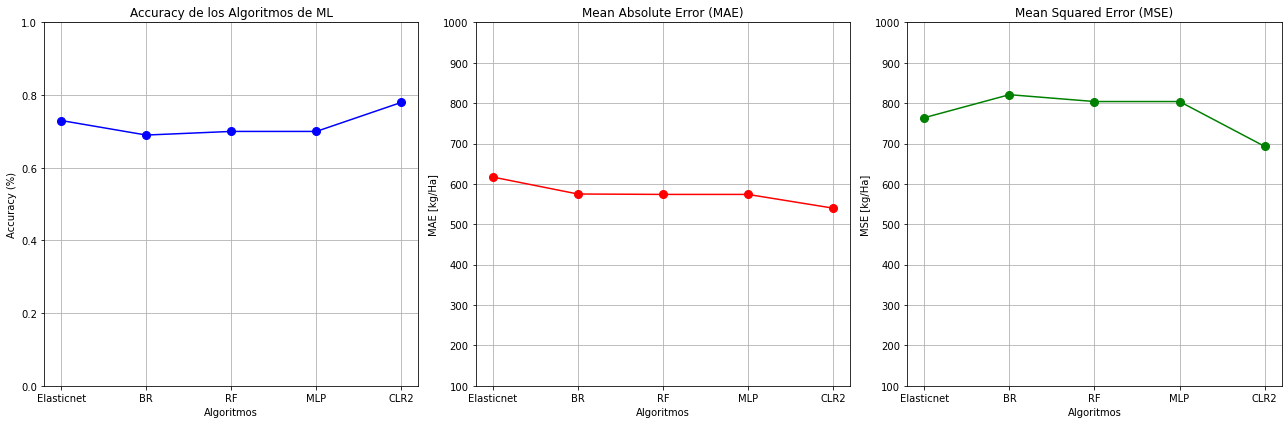

In [14]:
# ======================
# Nombres de los algoritmos
algoritmos = ['Elasticnet', 'BR', 'RF', 'MLP', 'CLR2']

# Valores de accuracy, MAE y MSE obteniedo por cada para cada algoritmo despues del proceso de validación cruzada
accuracy = [0.73, 0.69, 0.70, 0.70, 0.78]
mae = [617, 575, 574, 574, 540]
mse = [764, 821, 804, 804, 693]

# Crear la figura con 3 subgráficos en una fila
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graficar Accuracy con puntos y valores
axes[0].plot(algoritmos, accuracy, marker='o', color='b', label='Accuracy', linestyle='-', markersize=8)
axes[0].set_title('Accuracy de los Algoritmos de ML')
axes[0].set_xlabel('Algoritmos')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 1])
axes[0].grid(True)

# Añadir los valores de accuracy en cada punto
#for i, value in enumerate(accuracy):
#    axes[0].text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

# Graficar MAE con puntos y valores
axes[1].plot(algoritmos, mae, marker='o', color='r', label='MAE', linestyle='-', markersize=8)
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_xlabel('Algoritmos')
axes[1].set_ylabel('MAE [kg/Ha]')
axes[1].set_ylim([100, 1000])
axes[1].grid(True)

# Añadir los valores de MAE en cada punto
#for i, value in enumerate(mae):
#    axes[1].text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

# Graficar MSE con puntos y valores
axes[2].plot(algoritmos, mse, marker='o', color='g', label='MSE', linestyle='-', markersize=8)
axes[2].set_title('Mean Squared Error (MSE)')
axes[2].set_xlabel('Algoritmos')
axes[2].set_ylabel('MSE [kg/Ha]')
axes[2].set_ylim([100, 1000])
axes[2].grid(True)

# Añadir los valores de MSE en cada punto
#for i, value in enumerate(mse):
#    axes[2].text(i, value, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# Ajustar el espacio entre los subgráficos
plt.tight_layout()

# Mostrar la figura
plt.show()

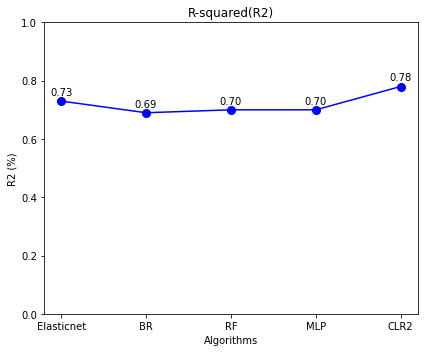

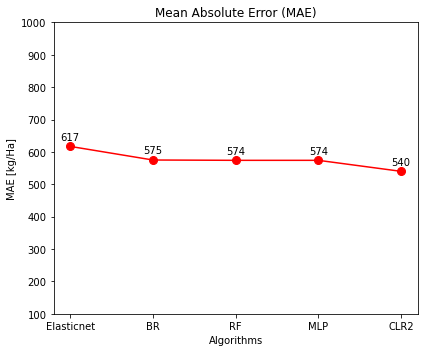

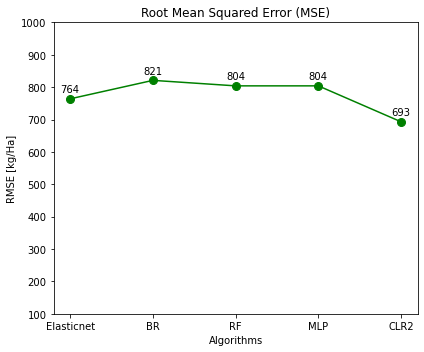

In [15]:

# Graficos individuales 
# =====================================================================

# Nombres de los algoritmos
# =====================================================================
algoritmos = ['Elasticnet', 'BR', 'RF', 'MLP', 'CLR2']

# Resultados obtenidos mediante validación cruzada de k_folders = 5
# ======================================================================
accuracy = [0.73, 0.69, 0.70, 0.70, 0.78]
mae = [617, 575, 574, 574, 540]
mse = [764, 821, 804, 804, 693]


# === GRÁFICO 1: Accuracy ===
plt.figure(figsize=(6, 5))
plt.plot(algoritmos, accuracy, marker='o', color='b', linestyle='-', markersize=8)
plt.title('R-squared(R2)')
plt.xlabel('Algorithms')
plt.ylabel('R2 (%)')
plt.ylim([0, 1])
plt.grid(False)

# Añadir etiquetas de valores
for i, value in enumerate(accuracy):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# === GRÁFICO 2: MAE ===
plt.figure(figsize=(6, 5))
plt.plot(algoritmos, mae, marker='o', color='r', linestyle='-', markersize=8)
plt.title('Mean Absolute Error (MAE)')
plt.xlabel('Algorithms')
plt.ylabel('MAE [kg/Ha]')
plt.ylim([100, 1000])
plt.grid(False)

for i, value in enumerate(mae):
    plt.text(i, value + 20, f'{value:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# === GRÁFICO 3: MSE ===
plt.figure(figsize=(6, 5))
plt.plot(algoritmos, mse, marker='o', color='g', linestyle='-', markersize=8)
plt.title('Root Mean Squared Error (MSE)')
plt.xlabel('Algorithms')
plt.ylabel('RMSE [kg/Ha]')
plt.ylim([100, 1000])
plt.grid(False)

for i, value in enumerate(mse):
    plt.text(i, value + 20, f'{value:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
